In [1]:
from google.colab import files
uploaded=files.upload()

Saving creditcardcsv.csv to creditcardcsv.csv


Dataset Shape: (10000, 10)

Columns:
Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

Target column: is_fraud

Fraud vs Non-Fraud Counts:
is_fraud
0    9849
1     151
Name: count, dtype: int64

Categorical Columns Detected: ['merchant_category']
Feature Shape after encoding: (10000, 12)

Train Fraud Ratio: 0.015125
Test Fraud Ratio: 0.015


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



===== Logistic Regression Performance =====
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.26      1.00      0.42        30

    accuracy                           0.96      2000
   macro avg       0.63      0.98      0.70      2000
weighted avg       0.99      0.96      0.97      2000


===== Random Forest Performance =====
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       1.00      0.53      0.70        30

    accuracy                           0.99      2000
   macro avg       1.00      0.77      0.85      2000
weighted avg       0.99      0.99      0.99      2000



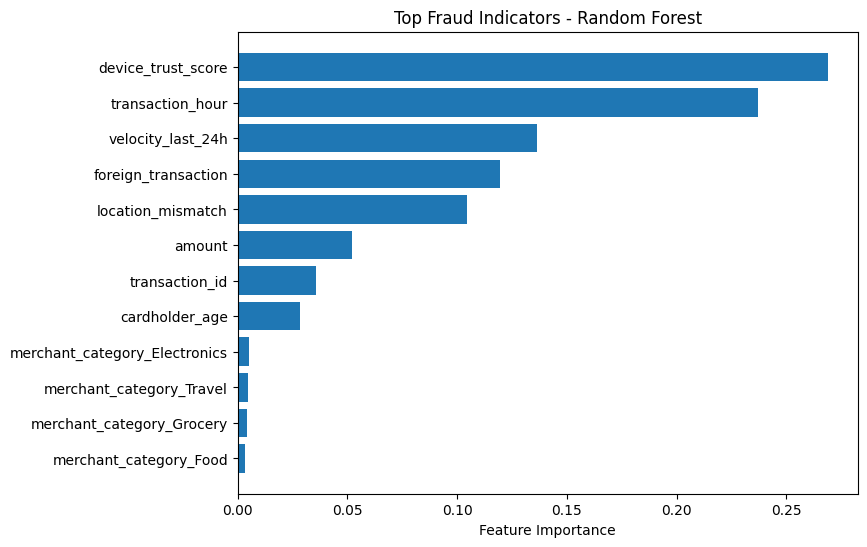


Model Comparison:
                 Model  Precision    Recall  F1-Score
0  Logistic Regression   0.263158  1.000000  0.416667
1        Random Forest   1.000000  0.533333  0.695652

Model Comparison:
                 Model  Precision    Recall  F1-Score
0  Logistic Regression   0.263158  1.000000  0.416667
1        Random Forest   1.000000  0.533333  0.695652

Best model saved as fraud_detection_random_forest.pkl


In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
df = pd.read_csv("creditcardcsv.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)
target_col = None
for col in df.columns:
    if col.lower() in ["class", "fraud", "is_fraud", "target", "label"]:
        target_col = col
        break

if target_col is None:
    raise ValueError("Target (fraud) column not found!")

print("\nTarget column:", target_col
print("\nFraud vs Non-Fraud Counts:")
print(df[target_col].value_counts())
X = df.drop(target_col, axis=1)
y = df[target_col]
for col in ["Time", "Id"]:
    if col in X.columns:
        X = X.drop(col, axis=1)
categorical_cols = X.select_dtypes(include=["object"]).columns
print("\nCategorical Columns Detected:", list(categorical_cols))

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Feature Shape after encoding:", X.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain Fraud Ratio:", y_train.mean())
print("Test Fraud Ratio:", y_test.mean())
lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("\n===== Logistic Regression Performance =====")
print(classification_report(y_test, y_pred_lr))

print("\n===== Random Forest Performance =====")
print(classification_report(y_test, y_pred_rf))
importances = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Top Fraud Indicators - Random Forest")
plt.show()
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

print("\nModel Comparison:")
print(comparison)
print("\nModel Comparison:")
print(comparison)
joblib.dump(rf, "fraud_detection_random_forest.pkl")
print("\nBest model saved as fraud_detection_random_forest.pkl")